In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from utils import readQuotes, MEDIAN, ATR, EMA, PERCENTILE
from backtrader_service import (
    Position,
    PositionDirection,
    calculate_cumulative_pnl,
    select_best_model,
    select_top_n_models,
    select_best_winrate,
    select_top_n_best_winrate,
    select_top_n_profit_by_trades,
)
from strategy_service import run_backtest, load_progress

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
ticker = 'SPBE'
df_base = readQuotes(f'..\download_data\{ticker}\{ticker}_1HOUR_history.txt')
df = df_base#.loc['2025-05-01 07:00:00':'2025-06-30 23:00:00',:].copy()

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_returns_and_trades(dates, returns, trades, strategy_name="Стратегия", benchmark_returns=None):
    """
    Построение графика с доходностью (линия) и количеством сделок (столбцы).
    
    Параметры:
    - dates: массив дат (или номеров периодов).
    - returns: массив доходности стратегии.
    - trades: массив количества сделок.
    - strategy_name: название стратегии (для легенды).
    - benchmark_returns: массив доходности бенчмарка (опционально).
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # График доходности (левая ось Y)
    color = 'tab:blue'
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Доходность руб/акц)', color=color)
    ax1.plot(dates, returns, color=color, label=f'{strategy_name} (доходность)')
    
    # Если есть бенчмарк, добавляем его на график
    if benchmark_returns is not None:
        ax1.plot(dates, benchmark_returns, color='tab:orange', linestyle='--', label='Бенчмарк')

    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Создаем вторую ось Y для количества сделок
    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Количество сделок', color=color)
    ax2.bar(dates, trades, color=color, alpha=0.3, label='Количество сделок', width=0.5)
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Объединяем легенды
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title(f'Доходность и количество сделок ({strategy_name})')
    fig.tight_layout()
    plt.show()
    

In [16]:
ra = [i / 10000 for i in range(100, 352, 10)]
# ra = [i / 10000 for i in range(100, 152, 10)]
# ra[6:]
len(ra)

26

In [17]:
ra

[0.01,
 0.011,
 0.012,
 0.013,
 0.014,
 0.015,
 0.016,
 0.017,
 0.018,
 0.019,
 0.02,
 0.021,
 0.022,
 0.023,
 0.024,
 0.025,
 0.026,
 0.027,
 0.028,
 0.029,
 0.03,
 0.031,
 0.032,
 0.033,
 0.034,
 0.035]

In [18]:
list(map(lambda x: 62*x, ra))

[0.62,
 0.6819999999999999,
 0.744,
 0.8059999999999999,
 0.868,
 0.9299999999999999,
 0.992,
 1.054,
 1.1159999999999999,
 1.178,
 1.24,
 1.302,
 1.3639999999999999,
 1.426,
 1.488,
 1.55,
 1.6119999999999999,
 1.674,
 1.736,
 1.798,
 1.8599999999999999,
 1.922,
 1.984,
 2.0460000000000003,
 2.108,
 2.1700000000000004]

In [7]:
# start_caliber, end_caliber, start_model, end_model, mark
# 6 месяцев калибровка, 2 месяца оценка
time_serial = [
    ('2024-01-01 07:00:00', '2024-06-30 23:45:00', '2024-07-01 07:00:00', '2024-08-31 23:45:00', '2024 июл-авг'),
    ('2024-03-01 07:00:00', '2024-08-31 23:45:00', '2024-09-01 07:00:00', '2024-10-31 23:45:00', '2024 сен-окт'),
    ('2024-05-01 07:00:00', '2024-10-31 23:45:00', '2024-11-01 07:00:00', '2024-12-31 23:45:00', '2024 ноя-дек'),
    ('2024-07-01 07:00:00', '2024-12-31 23:45:00', '2025-01-01 07:00:00', '2025-02-28 23:45:00', '2025 янв-фев'),
    ('2024-09-01 07:00:00', '2025-02-28 23:45:00', '2025-03-01 07:00:00', '2025-04-30 23:45:00', '2025 мар-апр'),
    ('2024-11-01 07:00:00', '2025-04-30 23:45:00', '2025-05-01 07:00:00', '2025-06-30 23:45:00', '2025 май-июн'),
]

In [9]:
# 12 месяцев калибровка, 1 месяца оценка
time_serial = [
    ('2024-01-01 06:00:00', '2024-12-31 23:45:00', '2024-12-01 06:00:00', '2025-01-01 06:00:00', '2025-01-31 23:45:00', '2025 янв'),
    ('2024-02-01 06:00:00', '2025-01-31 23:45:00', '2025-01-01 06:00:00', '2025-02-01 06:00:00', '2025-02-28 23:45:00', '2025 фев'),
    ('2024-03-01 06:00:00', '2025-02-28 23:45:00', '2025-02-01 06:00:00', '2025-03-01 06:00:00', '2025-03-31 23:45:00', '2025 мар'),
    ('2024-04-01 06:00:00', '2025-03-31 23:45:00', '2025-03-01 06:00:00', '2025-04-01 06:00:00', '2025-04-30 23:45:00', '2025 апр'),
    ('2024-05-01 06:00:00', '2025-04-30 23:45:00', '2025-04-01 06:00:00', '2025-05-01 06:00:00', '2025-05-31 23:45:00', '2025 май'),
    ('2024-06-01 06:00:00', '2025-05-31 23:45:00', '2025-05-01 06:00:00', '2025-06-01 06:00:00', '2025-06-30 23:45:00', '2025 июн'),
    ('2024-07-01 06:00:00', '2025-06-30 23:45:00', '2025-06-01 06:00:00', '2025-07-01 06:00:00', '2025-07-31 23:45:00', '2025 июл'),
    ('2024-08-01 06:00:00', '2025-07-31 23:45:00', '2025-07-01 06:00:00', '2025-08-01 06:00:00', '2025-08-31 23:45:00', '2025 авг'),
]

In [11]:
data1, data2, data3, data4, data5 = list(), list(), list(), list(), list()
direction = (True, False)

for strt_cal, end_cal, gap, strt_mdl, end_mdl, mrk in tqdm(time_serial):
    results = run_backtest(
        df.loc[strt_cal:end_cal,:].copy(),
        date_start='',
        median_range=range(20, 71, 5),
        # atr_range=range(4, 10),
        # coef_prof_range=range(1, 4),
        # coef_loss_range=range(1, 4),
        atr_range=[1],
        coef_prof_range=ra,
        coef_loss_range=ra,
        filename='pickle/sep_opti_median_CHMF_30Min.pickle',
        is_save=False,
        direction=direction
    )
    models = select_top_n_profit_by_trades(results, 5) # средний профит на сделку *(GAZP)
    # models = select_top_n_models(results, 5) # лучший доход *(aflt)
    # models = select_top_n_best_winrate(results, 5)  # лучшее соотношение положителных сделок к отрицательным *(aflt)
    model1 = models[0][0]
    model2 = models[1][0]
    model3 = models[2][0]
    model4 = models[3][0]
    model5 = models[4][0]
    # print(model)
    results = run_backtest(
        df.loc[gap:end_mdl,:].copy(),
        date_start=strt_mdl,
        median_range=range(20, 71, 5),
        # atr_range=range(4, 10),
        # coef_prof_range=range(1, 4),
        # coef_loss_range=range(1, 4),
        atr_range=[1],
        coef_prof_range=ra,
        coef_loss_range=ra,
        filename='pickle/sep_opti_median_CHMF_30Min.pickle',
        is_save=False,
        direction=direction
    )

    _, pnl1 = calculate_cumulative_pnl(results[model1])
    _, pnl2 = calculate_cumulative_pnl(results[model2])
    _, pnl3 = calculate_cumulative_pnl(results[model3])
    _, pnl4 = calculate_cumulative_pnl(results[model4])
    _, pnl5 = calculate_cumulative_pnl(results[model5])
    data1.append((mrk, (pnl1[-1] if len(pnl1)>0 else 0, len(pnl1), model1)))
    data2.append((mrk, (pnl2[-1] if len(pnl2)>0 else 0, len(pnl2), model2)))
    data3.append((mrk, (pnl3[-1] if len(pnl3)>0 else 0, len(pnl3), model3)))
    data4.append((mrk, (pnl4[-1] if len(pnl4)>0 else 0, len(pnl4), model4)))
    data5.append((mrk, (pnl5[-1] if len(pnl5)>0 else 0, len(pnl5), model5)))


  0%|          | 0/8 [00:00<?, ?it/s]

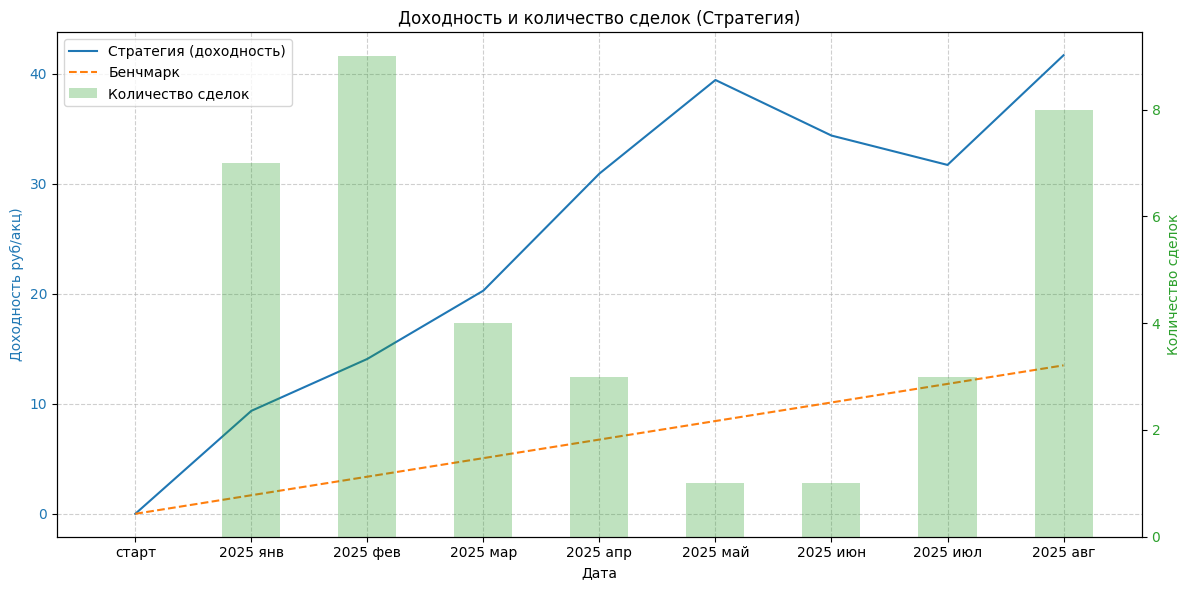

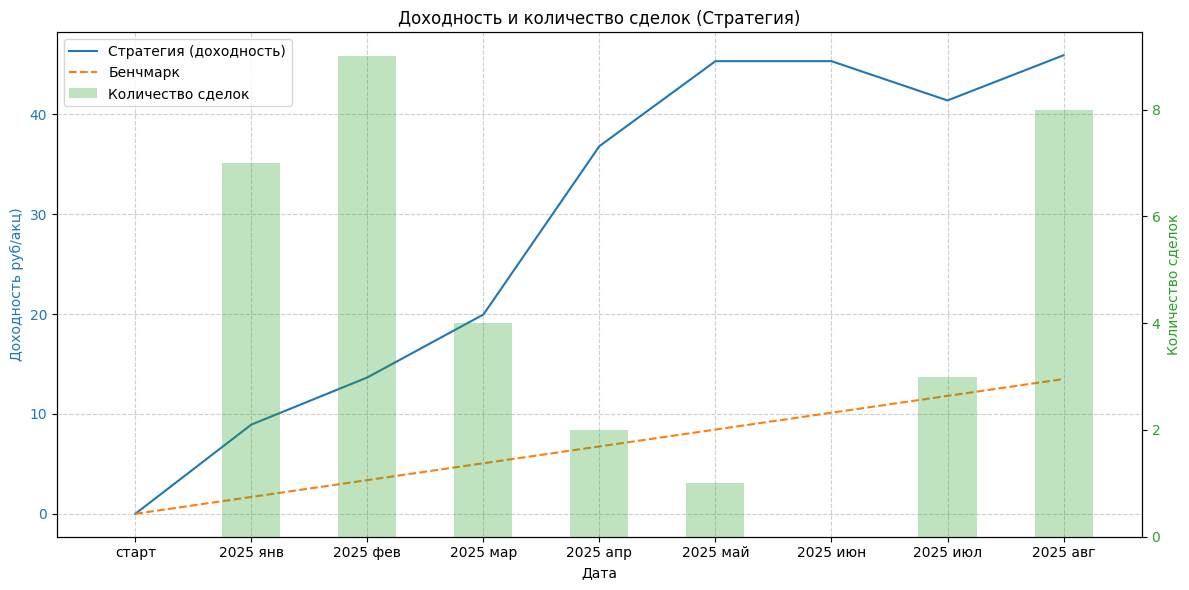

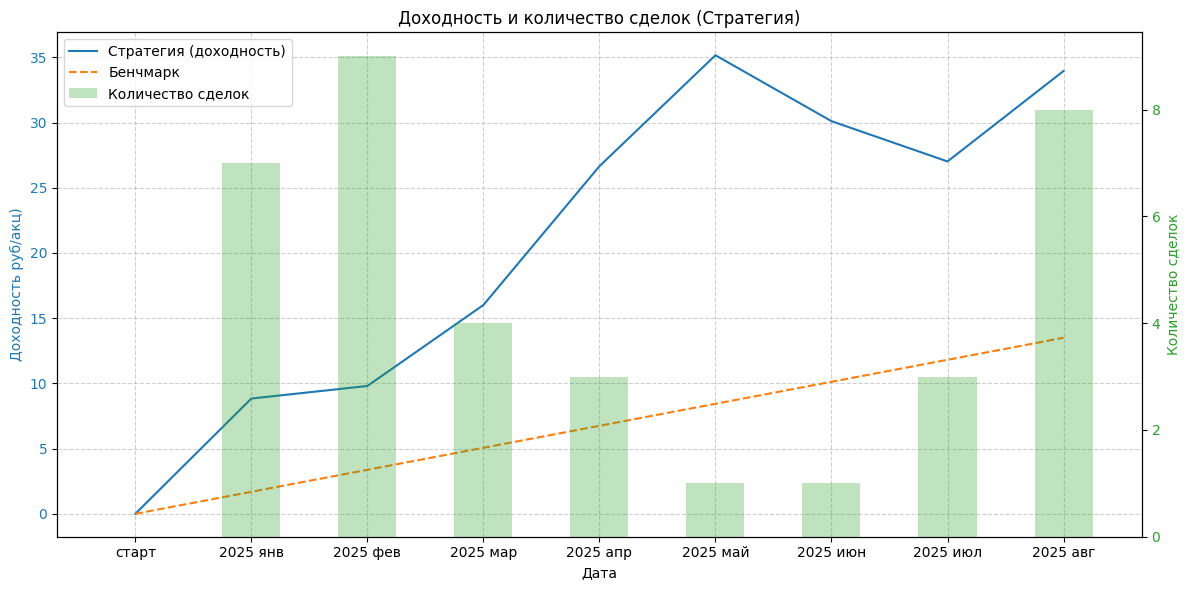

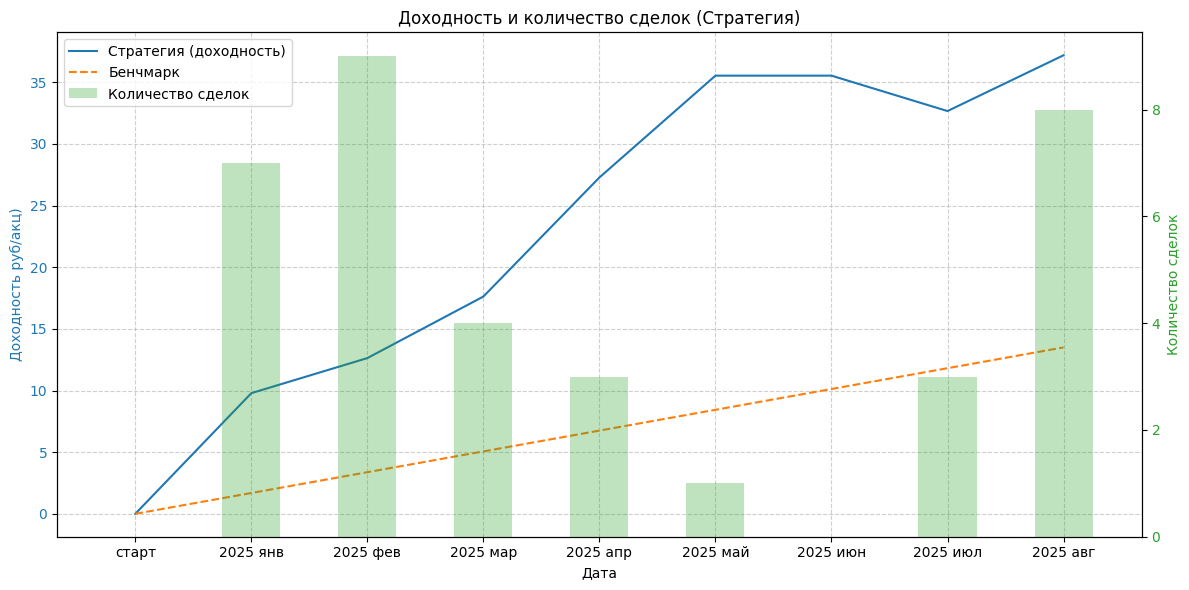

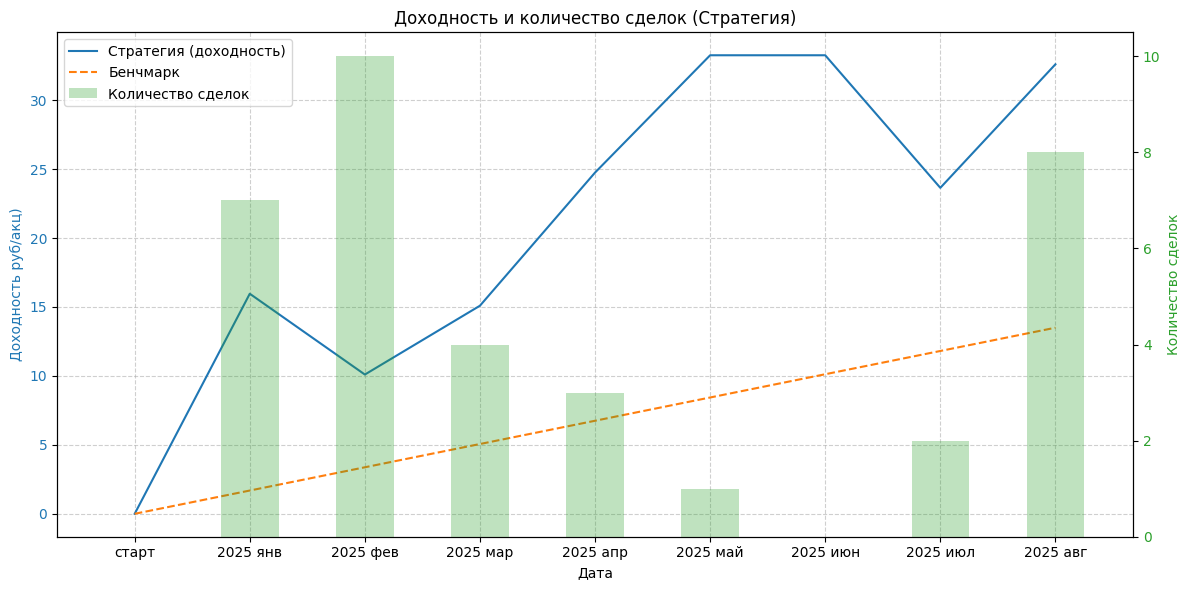

In [12]:
# ориентир на 1% в месяц -> 12% годовых
# поэтому и делим на 100%
bench_mark = list(map(lambda x: x*(df['close'].mean() / 100), range(len(time_serial)+1)))
for res in [data1, data2, data3, data4, data5]:
    returns = [0]
    for i in res:
        returns.append(returns[-1] + i[1][0])
    x = ['старт'] + [i[0] for i in res]
    trades = [0] + [i[1][1] for i in res]
    plot_returns_and_trades(x, returns, trades, benchmark_returns=bench_mark)

In [62]:
import pandas as pd
import numpy as np

# Предположим, у вас есть DataFrame с колонками:
# 'datetime' - дата и время
# 'close' - цена закрытия
# Пример данных:
# df = pd.read_csv('your_data.csv', parse_dates=['datetime'])

# Убедимся, что данные отсортированы по времени
# df = df.sort_values('datetime')

df['datetime'] = df.index

# Создадим колонки для месяца и года для группировки
df['year_month'] = df['datetime'].dt.to_period('M')

# Рассчитаем часовую доходность (логарфимическую)
df['hourly_returns'] = np.log(df['close'] / df['close'].shift(1))

# Группируем по месяцу и считаем стандартное отклонение доходностей (волатильность)
monthly_volatility = df.groupby('year_month')['hourly_returns'].std()

# Переведем в годовую волатильность (поскольку данные часовые)
# Умножаем на sqrt(24*252) - 24 часа в сутках, 252 торговых дня в году
monthly_volatility_annualized = monthly_volatility * np.sqrt(24 * 252)

# Результат: волатильность по месяцам (годовая)
print(monthly_volatility_annualized)

year_month
2024-01    0.148455
2024-02    0.152629
2024-03    0.146813
2024-04    0.217885
2024-05    0.398019
2024-06    0.416172
2024-07    0.460462
2024-08    0.401769
2024-09    0.486379
2024-10    0.356871
2024-11    0.458067
2024-12    0.451715
2025-01    0.404708
2025-02    0.559167
2025-03    0.407333
2025-04    0.565877
2025-05    0.440667
2025-06    0.272310
Freq: M, Name: hourly_returns, dtype: float64


In [14]:
import os

In [10]:
ticker = 'AFLT'
df_base = readQuotes(f'..\download_data\{ticker}\{ticker}_1HOUR_history.txt')
df = df_base#.loc['2025-05-01 07:00:00':'2025-06-30 23:00:00',:].copy()

# Сбор общего пайплайна для отбора инструментов

In [15]:
tools = []
exclude_tools = {'CNYRUBF', 'load_moex_candles.py', 'SiZ4_5Min.txt', 'temp.txt'}
exclde_tools_bug = {'DIAS', 'HEAD', 'LEAS', 'MBNK', 'OZPH', 'RAGR'}
for f in os.listdir(os.path.join('c:\QUIK_VTB\scripts', 'download_data')):
    if f in exclude_tools or f in exclde_tools_bug:
        continue
    tools.append(f)

In [19]:
dict_result = dict()
dict_result_ = dict()
dict_result__ = dict()
garbage = []
for ticker in tqdm(tools, desc='Tiker'):
    try:
        df_base = readQuotes(f'..\download_data\{ticker}\{ticker}_1HOUR_history.txt')
        df = df_base.copy()
        data1_n_model, data2_n_model, data3_n_model, data4_n_model, data5_n_model = list(), list(), list(), list(), list()
        data1_best_win, data2_best_win, data3_best_win, data4_best_win, data5_best_win = list(), list(), list(), list(), list()
        data1_best_profit, data2_best_profit, data3_best_profit, data4_best_profit, data5_best_profit = list(), list(), list(), list(), list()

        direction = (True, False)

        for strt_cal, end_cal, gap, strt_mdl, end_mdl, mrk in time_serial:
            results = run_backtest(
                df.loc[strt_cal:end_cal,:].copy(),
                date_start='',
                median_range=range(20, 71, 5),
                # atr_range=range(4, 10),
                # coef_prof_range=range(1, 4),
                # coef_loss_range=range(1, 4),
                atr_range=[1],
                coef_prof_range=ra,
                coef_loss_range=ra,
                filename='pickle/sep_opti_median_CHMF_30Min.pickle',
                is_save=False,
                direction=direction
            )
            models_by_profit = select_top_n_profit_by_trades(results, 5) # средний профит на сделку *(GAZP)
            models_n_model = select_top_n_models(results, 5) # лучший доход *(aflt)
            models_best_win = select_top_n_best_winrate(results, 5)  # лучшее соотношение положителных сделок к отрицательным *(aflt)
            model1_n_model = models_n_model[0][0]
            model2_n_model = models_n_model[1][0]
            model3_n_model = models_n_model[2][0]
            model4_n_model = models_n_model[3][0]
            model5_n_model = models_n_model[4][0]
            model1_best_win = models_best_win[0][0]
            model2_best_win = models_best_win[1][0]
            model3_best_win = models_best_win[2][0]
            model4_best_win = models_best_win[3][0]
            model5_best_win = models_best_win[4][0]
            model1_by_profit = models_by_profit[0][0]
            model2_by_profit = models_by_profit[1][0]
            model3_by_profit = models_by_profit[2][0]
            model4_by_profit = models_by_profit[3][0]
            model5_by_profit = models_by_profit[4][0]
            # print(model)
            results = run_backtest(
                df.loc[gap:end_mdl,:].copy(),
                date_start=strt_mdl,
                median_range=range(20, 71, 5),
                # atr_range=range(4, 10),
                # coef_prof_range=range(1, 4),
                # coef_loss_range=range(1, 4),
                atr_range=[1],
                coef_prof_range=ra,
                coef_loss_range=ra,
                filename='pickle/sep_opti_median_CHMF_30Min.pickle',
                is_save=False,
                direction=direction
            )

            _, pnl1 = calculate_cumulative_pnl(results[model1_n_model])
            _, pnl2 = calculate_cumulative_pnl(results[model2_n_model])
            _, pnl3 = calculate_cumulative_pnl(results[model3_n_model])
            _, pnl4 = calculate_cumulative_pnl(results[model4_n_model])
            _, pnl5 = calculate_cumulative_pnl(results[model5_n_model])

            _, pnl1_ = calculate_cumulative_pnl(results[model1_best_win])
            _, pnl2_ = calculate_cumulative_pnl(results[model2_best_win])
            _, pnl3_ = calculate_cumulative_pnl(results[model3_best_win])
            _, pnl4_ = calculate_cumulative_pnl(results[model4_best_win])
            _, pnl5_ = calculate_cumulative_pnl(results[model5_best_win])

            _, pnl1__ = calculate_cumulative_pnl(results[model1_by_profit])
            _, pnl2__ = calculate_cumulative_pnl(results[model2_by_profit])
            _, pnl3__ = calculate_cumulative_pnl(results[model3_by_profit])
            _, pnl4__ = calculate_cumulative_pnl(results[model4_by_profit])
            _, pnl5__ = calculate_cumulative_pnl(results[model5_by_profit])

            data1_n_model.append((mrk, (pnl1[-1] if len(pnl1)>0 else 0, len(pnl1), model1_n_model)))
            data2_n_model.append((mrk, (pnl2[-1] if len(pnl2)>0 else 0, len(pnl2), model2_n_model)))
            data3_n_model.append((mrk, (pnl3[-1] if len(pnl3)>0 else 0, len(pnl3), model3_n_model)))
            data4_n_model.append((mrk, (pnl4[-1] if len(pnl4)>0 else 0, len(pnl4), model4_n_model)))
            data5_n_model.append((mrk, (pnl5[-1] if len(pnl5)>0 else 0, len(pnl5), model5_n_model)))

            data1_best_win.append((mrk, (pnl1_[-1] if len(pnl1_)>0 else 0, len(pnl1_), model1_best_win)))
            data2_best_win.append((mrk, (pnl2_[-1] if len(pnl2_)>0 else 0, len(pnl2_), model2_best_win)))
            data3_best_win.append((mrk, (pnl3_[-1] if len(pnl3_)>0 else 0, len(pnl3_), model3_best_win)))
            data4_best_win.append((mrk, (pnl4_[-1] if len(pnl4_)>0 else 0, len(pnl4_), model4_best_win)))
            data5_best_win.append((mrk, (pnl5_[-1] if len(pnl5_)>0 else 0, len(pnl5_), model5_best_win)))

            data1_best_profit.append((mrk, (pnl1__[-1] if len(pnl1__)>0 else 0, len(pnl1__), model1_by_profit)))
            data2_best_profit.append((mrk, (pnl2__[-1] if len(pnl2__)>0 else 0, len(pnl2__), model2_by_profit)))
            data3_best_profit.append((mrk, (pnl3__[-1] if len(pnl3__)>0 else 0, len(pnl3__), model3_by_profit)))
            data4_best_profit.append((mrk, (pnl4__[-1] if len(pnl4__)>0 else 0, len(pnl4__), model4_by_profit)))
            data5_best_profit.append((mrk, (pnl5__[-1] if len(pnl5__)>0 else 0, len(pnl5__), model5_by_profit)))

        bench = (df['close'].mean()) / 100 * len(time_serial)
        dict_result[ticker] = {
            'top_1': data1_n_model,
            'top_2': data2_n_model,
            'top_3': data3_n_model,
            'top_4': data4_n_model,
            'top_5': data5_n_model,
            'bench': bench
        }
        dict_result_[ticker] = {
            'top_1': data1_best_win,
            'top_2': data2_best_win,
            'top_3': data3_best_win,
            'top_4': data4_best_win,
            'top_5': data5_best_win,
            'bench': bench
        }
        dict_result__[ticker] = {
            'top_1': data1_best_profit,
            'top_2': data2_best_profit,
            'top_3': data3_best_profit,
            'top_4': data4_best_profit,
            'top_5': data5_best_profit,
            'bench': bench
        }
    except Exception as err:
        print(f'Проблема с {ticker}: {err}')
        garbage.append(ticker)

Tiker:   0%|          | 0/68 [00:00<?, ?it/s]

Произошла ошибка: index 0 is out of bounds for axis 0 with size 0
Сохраняем текущий прогресс перед выходом...
Проблема с CNRU: index 0 is out of bounds for axis 0 with size 0


Произошла ошибка: index 0 is out of bounds for axis 0 with size 0
Сохраняем текущий прогресс перед выходом...
Проблема с IVAT: index 0 is out of bounds for axis 0 with size 0


Произошла ошибка: index 0 is out of bounds for axis 0 with size 0
Сохраняем текущий прогресс перед выходом...
Проблема с UPRO: index 0 is out of bounds for axis 0 with size 0


Произошла ошибка: index 0 is out of bounds for axis 0 with size 0
Сохраняем текущий прогресс перед выходом...
Проблема с VSMO: index 0 is out of bounds for axis 0 with size 0


Произошла ошибка: index 0 is out of bounds for axis 0 with size 0
Сохраняем текущий прогресс перед выходом...
Проблема с X5: index 0 is out of bounds for axis 0 with size 0


Проблема с _IMOEX: [Errno 2] No such file or directory: '..\\download_data\\_IMOEX\\_IMOEX_1HOUR_history.txt'


In [20]:
len(garbage)

6

In [21]:
garbage

['CNRU', 'IVAT', 'UPRO', 'VSMO', 'X5', '_IMOEX']

In [48]:
dict_result_['AFKS']['top_5']

[('2025 янв',
  (-0.9951835888000018,
   3,
   'period_ema=65:period_atr=1:coef_prof=0.035:coef_loss=0.021')),
 ('2025 фев',
  (0.15660967039999601,
   7,
   'period_ema=65:period_atr=1:coef_prof=0.031:coef_loss=0.021')),
 ('2025 мар',
  (0.7065700816000011,
   3,
   'period_ema=65:period_atr=1:coef_prof=0.031:coef_loss=0.021')),
 ('2025 апр',
  (0.5342468295999996,
   3,
   'period_ema=65:period_atr=1:coef_prof=0.03:coef_loss=0.021')),
 ('2025 май',
  (0.9899388251999993,
   4,
   'period_ema=65:period_atr=1:coef_prof=0.03:coef_loss=0.021')),
 ('2025 июн',
  (0.4020088999999974,
   6,
   'period_ema=65:period_atr=1:coef_prof=0.03:coef_loss=0.02')),
 ('2025 июл',
  (0.9801427819999997,
   4,
   'period_ema=50:period_atr=1:coef_prof=0.029:coef_loss=0.02')),
 ('2025 авг',
  (0.6769903620000026,
   5,
   'period_ema=40:period_atr=1:coef_prof=0.03:coef_loss=0.021'))]

In [52]:
d_best = pd.DataFrame(columns=['tiker', 'top', 'prof_months', 'profit', 'bench'])

for k, v in dict_result__.items():
    for top in ('top_1','top_2','top_3','top_4','top_5'):
        prof_months = sum([it[1][0] >= 0 for it in v[top]])
        prof_sum = sum([it[1][0] for it in v[top]])
        if prof_months > 5:
            d_best.loc[-1] = [k, top, f'{prof_months}/8', prof_sum, v['bench']]
            d_best.index = d_best.index + 1
            d_best = d_best.sort_index()

In [53]:
d_best[(d_best['prof_months'].isin(['6/8', '7/8', '8/8'])) & (d_best['profit'] >= d_best['bench'])]

,tiker,top,prof_months,profit,bench
0,VTBR,top_5,6/8,9.656265,7.546571
1,VTBR,top_4,6/8,10.379180,7.546571
2,VTBR,top_3,6/8,11.457012,7.546571
3,VTBR,top_2,6/8,12.598039,7.546571
4,VTBR,top_1,6/8,8.468977,7.546571
7,VSEH,top_2,6/8,10.398015,7.889873
9,TATN,top_5,6/8,103.848870,53.345146
10,TATN,top_4,7/8,102.709529,53.345146
11,SPBE,top_5,6/8,35.636804,13.497180
12,SPBE,top_4,7/8,41.673326,13.497180


## Модель на след месяц

In [144]:
ticker = 'LENT'
df_base = readQuotes(f'..\download_data\{ticker}\{ticker}_1HOUR_history.txt')
df = df_base#.loc['2025-05-01 07:00:00':'2025-06-30 23:00:00',:].copy()

In [145]:
strt_cal='2024-09-01 06:00:00'
end_cal='2025-08-31 23:45:00'
results = run_backtest(
    df.loc[strt_cal:end_cal,:].copy(),
    date_start='',
    median_range=range(20, 71, 5),
    # atr_range=range(4, 10),
    # coef_prof_range=range(1, 4),
    # coef_loss_range=range(1, 4),
    atr_range=[1],
    coef_prof_range=ra,
    coef_loss_range=ra,
    filename='pickle/sep_opti_median_CHMF_30Min.pickle',
    is_save=False,
    direction=direction
)
models = select_top_n_profit_by_trades(results, 5) # средний профит на сделку *(GAZP)
# models = select_top_n_models(results, 5) # лучший доход *(aflt)
# models = select_top_n_best_winrate(results, 5)  # лучшее соотношение положителных сделок к отрицательным *(aflt)
model1 = models[0][0]
model2 = models[1][0]
model3 = models[2][0]
model4 = models[3][0]
model5 = models[4][0]

In [147]:
print(f'{model1=}')
print(f'{model2=}')
print(f'{model3=}')
print(f'{model4=}')
print(f'{model5=}')

model1='period_ema=25:period_atr=1:coef_prof=0.035:coef_loss=0.025'
model2='period_ema=25:period_atr=1:coef_prof=0.034:coef_loss=0.024'
model3='period_ema=25:period_atr=1:coef_prof=0.035:coef_loss=0.024'
model4='period_ema=25:period_atr=1:coef_prof=0.034:coef_loss=0.022'
model5='period_ema=50:period_atr=1:coef_prof=0.035:coef_loss=0.025'


In [106]:
models[1]

('period_ema=70:period_atr=1:coef_prof=0.035:coef_loss=0.025',
 42.094157999999894)